In [1]:
# statistical_analysis.py
# Simple stats workflow:
# 1) z-scores within seed + boxplots
# 2) Friedman ANOVA (>=3 configs)
# 3) Wilcoxon signed-rank post-hoc (pairwise between configs, Bonferroni)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# ----------------------------
# 1) Z-scores + boxplots
# # ----------------------------
# def zscores_and_boxplots(df, seed_col, config_col, configs, measures, make_plots=True):
#     """
#     - Filters df to selected configs
#     - Keeps only seeds present in all configs (paired)
#     - Computes z-scores per seed (across configs) for each measure
#     - Optionally plots boxplots per measure (one plot per measure)
#     Returns: d (filtered df with <measure>_z columns), wide_tables (dict measure->wide z table)
#     """
#     d = df[df[config_col].isin(configs)].copy()
#     d[seed_col] = d[seed_col].astype(str)
# 
#     common_seeds = set.intersection(*[set(d.loc[d[config_col] == c, seed_col]) for c in configs])
#     d = d[d[seed_col].isin(common_seeds)].copy()
# 
#     for m in measures:
#         d[m] = pd.to_numeric(d[m], errors="coerce")
#         mu = d.groupby(seed_col)[m].transform("mean")
#         sd = d.groupby(seed_col)[m].transform(lambda x: x.std(ddof=0))
#         d[m + "_z"] = (d[m] - mu) / sd.replace(0, np.nan)
# 
#     wide_tables = {}
#     for m in measures:
#         zc = m + "_z"
#         wide = d.pivot_table(index=seed_col, columns=config_col, values=zc, aggfunc="mean")
#         wide = wide[configs].dropna(axis=0, how="any")
#         wide_tables[m] = wide
# 
#         if make_plots:
#             groups = [wide[c].to_numpy() for c in wide.columns]
#             plt.figure(figsize=(12, 4))
#             plt.boxplot(groups, labels=list(wide.columns), showmeans=True)
#             plt.axhline(0.0, linestyle="--")
#             plt.title(f"{m} (z-scores within seed)")
#             plt.ylabel("z-score [-]")
#             plt.xticks(rotation=35, ha="right")
#             plt.tight_layout()
#             plt.show()
# 
#     return d, wide_tables
# 
# 
# # ----------------------------
# # 2) Friedman ANOVA
# # ----------------------------
# def friedman_anova(df, seed_col, config_col, configs, measures, use_zscores=True):
#     """
#     - Filters df to selected configs
#     - Keeps only paired seeds across configs
#     - Runs Friedman per measure
#     Returns: friedman_results (DataFrame), wide_tables (dict measure->wide table used)
#     """
#     d = df[df[config_col].isin(configs)].copy()
#     d[seed_col] = d[seed_col].astype(str)
# 
#     common_seeds = set.intersection(*[set(d.loc[d[config_col] == c, seed_col]) for c in configs])
#     d = d[d[seed_col].isin(common_seeds)].copy()
# 
#     if use_zscores:
#         for m in measures:
#             d[m] = pd.to_numeric(d[m], errors="coerce")
#             mu = d.groupby(seed_col)[m].transform("mean")
#             sd = d.groupby(seed_col)[m].transform(lambda x: x.std(ddof=0))
#             d[m + "_z"] = (d[m] - mu) / sd.replace(0, np.nan)
# 
#     rows = []
#     wide_tables = {}
# 
#     for m in measures:
#         col = (m + "_z") if use_zscores else m
#         wide = d.pivot_table(index=seed_col, columns=config_col, values=col, aggfunc="mean")
#         wide = wide[configs].dropna(axis=0, how="any")
#         wide_tables[m] = wide
# 
#         arrays = [wide[c].to_numpy() for c in wide.columns]
#         chi2, p = stats.friedmanchisquare(*arrays)
# 
#         n, k = wide.shape
#         W = chi2 / (n * (k - 1))  # Kendall's W
#         df_chi2 = k - 1
# 
#         rows.append({
#             "measure": m,
#             "chi2": float(chi2),
#             "df": int(df_chi2),
#             "p": float(p),
#             "n": int(n),
#             "k": int(k),
#             "kendall_W": float(W),
#         })
# 
#     friedman_results = pd.DataFrame(rows).sort_values("p")
#     return friedman_results, wide_tables
# 
# 
# # ----------------------------
# # 3) Wilcoxon post-hoc (pairwise)
# # ----------------------------
# def wilcoxon_posthoc(df, seed_col, config_col, configs, measures, use_zscores=True, correction="bonferroni"):
#     """
#     - Filters df to selected configs
#     - Keeps only paired seeds across configs
#     - Runs pairwise Wilcoxon signed-rank per measure
#     - Bonferroni by default: p_adj = p_raw * (#pairs)
#     Returns: posthoc_results (DataFrame)
#     """
#     d = df[df[config_col].isin(configs)].copy()
#     d[seed_col] = d[seed_col].astype(str)
# 
#     common_seeds = set.intersection(*[set(d.loc[d[config_col] == c, seed_col]) for c in configs])
#     d = d[d[seed_col].isin(common_seeds)].copy()
# 
#     if use_zscores:
#         for m in measures:
#             d[m] = pd.to_numeric(d[m], errors="coerce")
#             mu = d.groupby(seed_col)[m].transform("mean")
#             sd = d.groupby(seed_col)[m].transform(lambda x: x.std(ddof=0))
#             d[m + "_z"] = (d[m] - mu) / sd.replace(0, np.nan)
# 
#     pairs = [(configs[i], configs[j]) for i in range(len(configs)) for j in range(i + 1, len(configs))]
#     n_pairs = len(pairs)
# 
#     rows = []
#     for m in measures:
#         col = (m + "_z") if use_zscores else m
#         wide = d.pivot_table(index=seed_col, columns=config_col, values=col, aggfunc="mean")
#         wide = wide[configs].dropna(axis=0, how="any")
# 
#         for a, b in pairs:
#             x = wide[a].to_numpy()
#             y = wide[b].to_numpy()
# 
#             stat, p = stats.wilcoxon(x, y)
#             rows.append({
#                 "measure": m,
#                 "A": a,
#                 "B": b,
#                 "stat": float(stat),
#                 "p_raw": float(p),
#                 "n": int(len(x)),
#                 "median_diff": float(np.median(x - y)),
#                 "mean_diff": float(np.mean(x - y)),
#             })
# 
#     posthoc = pd.DataFrame(rows)
# 
#     if correction == "bonferroni":
#         posthoc["p_adj"] = posthoc["p_raw"] * n_pairs
#     else:
#         posthoc["p_adj"] = posthoc["p_raw"]
# 
#     return posthoc.sort_values(["measure", "p_adj", "p_raw"])

In [2]:
# ----------------------------
# Helpers: paired data + optional within-unit z-scores
# ----------------------------

def _paired_long(df, unit_col, condition_col, conditions, measures):
    """Filter to conditions and keep only units present in all conditions."""
    d = df[df[condition_col].isin(conditions)].copy()
    d[unit_col] = d[unit_col].astype(str)

    # Keep only units that exist in ALL conditions (paired)
    common_units = set.intersection(*[set(d.loc[d[condition_col] == c, unit_col]) for c in conditions])
    d = d[d[unit_col].isin(common_units)].copy()

    # Coerce measures to numeric
    for m in measures:
        d[m] = pd.to_numeric(d[m], errors="coerce")

    return d


def _add_within_unit_zscores(d, unit_col, measures):
    """Add <measure>_z columns computed within each unit across conditions."""
    out = d.copy()
    for m in measures:
        mu = out.groupby(unit_col)[m].transform("mean")
        sd = out.groupby(unit_col)[m].transform(lambda x: x.std(ddof=0))
        out[m + "_z"] = (out[m] - mu) / sd.replace(0, np.nan)
    return out


def _paired_wide(d, unit_col, condition_col, conditions, measure_col):
    """Return wide table (index=unit, columns=condition) used for paired tests."""
    wide = d.pivot_table(index=unit_col, columns=condition_col, values=measure_col, aggfunc="mean")
    wide = wide[conditions].dropna(axis=0, how="any")  # preserve order + complete cases
    return wide


# ----------------------------
# 1) Z-scores + boxplots
# ----------------------------
def zscores_and_boxplots(df, seed_col, config_col, configs, measures, make_plots=True):
    """
    - Filters df to selected configs
    - Keeps only seeds present in all configs (paired)
    - Computes z-scores per seed (across configs) for each measure
    - Optionally plots boxplots per measure (one plot per measure)
    Returns: d (filtered df with <measure>_z columns), wide_tables (dict measure->wide z table)
    """
    d = _paired_long(df, unit_col=seed_col, condition_col=config_col, conditions=configs, measures=measures)
    d = _add_within_unit_zscores(d, unit_col=seed_col, measures=measures)

    wide_tables = {}
    for m in measures:
        zc = m + "_z"
        wide = _paired_wide(d, unit_col=seed_col, condition_col=config_col, conditions=configs, measure_col=zc)
        wide_tables[m] = wide

        if make_plots:
            groups = [wide[c].to_numpy() for c in wide.columns]
            plt.figure(figsize=(12, 4))
            plt.boxplot(groups, labels=list(wide.columns), showmeans=True)
            plt.axhline(0.0, linestyle="--")
            plt.title(f"{m} (z-scores within seed)")
            plt.ylabel("z-score [-]")
            plt.xticks(rotation=35, ha="right")
            plt.tight_layout()
            plt.show()

    return d, wide_tables


# ----------------------------
# 2) Friedman ANOVA
# ----------------------------
def friedman_anova(df, seed_col, config_col, configs, measures, use_zscores=True):
    """
    - Filters df to selected configs
    - Keeps only paired seeds across configs
    - Runs Friedman per measure
    Returns: friedman_results (DataFrame), wide_tables (dict measure->wide table used)

    Note: Friedman is rank-based, so z-scoring is not required for validity.
    """
    d = _paired_long(df, unit_col=seed_col, condition_col=config_col, conditions=configs, measures=measures)
    if use_zscores:
        d = _add_within_unit_zscores(d, unit_col=seed_col, measures=measures)

    rows = []
    wide_tables = {}

    for m in measures:
        col = (m + "_z") if use_zscores else m
        wide = _paired_wide(d, unit_col=seed_col, condition_col=config_col, conditions=configs, measure_col=col)
        wide_tables[m] = wide

        arrays = [wide[c].to_numpy() for c in wide.columns]
        chi2, p = stats.friedmanchisquare(*arrays)

        n, k = wide.shape
        W = chi2 / (n * (k - 1))  # Kendall's W
        df_chi2 = k - 1

        rows.append({
            "measure": m,
            "chi2": float(chi2),
            "df": int(df_chi2),
            "p": float(p),
            "n": int(n),
            "k": int(k),
            "kendall_W": float(W),
            "used_zscores": bool(use_zscores),
        })

    friedman_results = pd.DataFrame(rows).sort_values("p")
    return friedman_results, wide_tables


# ----------------------------
# 3) Wilcoxon post-hoc (pairwise)
# ----------------------------
def wilcoxon_posthoc(
    df,
    seed_col,
    config_col,
    configs,
    measures,
    use_zscores=True,
    correction="bonferroni",
    wilcoxon_zero_method="wilcox",
    wilcoxon_mode="auto",
):
    """
    - Filters df to selected configs
    - Keeps only paired seeds across configs
    - Runs pairwise Wilcoxon signed-rank per measure

    correction:
      - "bonferroni": p_adj = min(p_raw * #pairs, 1.0)
      - anything else: p_adj = p_raw

    wilcoxon_zero_method:
      - "wilcox" (default) / "pratt" / "zsplit"

    wilcoxon_mode:
      - "auto" (scipy default) / "exact" / "approx"
    """
    d = _paired_long(df, unit_col=seed_col, condition_col=config_col, conditions=configs, measures=measures)
    if use_zscores:
        d = _add_within_unit_zscores(d, unit_col=seed_col, measures=measures)

    pairs = [(configs[i], configs[j]) for i in range(len(configs)) for j in range(i + 1, len(configs))]
    n_pairs = len(pairs)

    rows = []
    for m in measures:
        col = (m + "_z") if use_zscores else m
        wide = _paired_wide(d, unit_col=seed_col, condition_col=config_col, conditions=configs, measure_col=col)

        for a, b in pairs:
            x = wide[a].to_numpy()
            y = wide[b].to_numpy()
            diff = x - y

            # All diffs ~0 => nothing to test
            if np.all(np.isfinite(diff)) and np.allclose(diff, 0.0):
                stat, p = 0.0, 1.0
            else:
                try:
                    stat, p = stats.wilcoxon(
                        x, y,
                        zero_method=wilcoxon_zero_method,
                        mode=wilcoxon_mode,
                    )
                except Exception:
                    stat, p = np.nan, np.nan

            rows.append({
                "measure": m,
                "A": a,
                "B": b,
                "stat": float(stat) if stat is not None else np.nan,
                "p_raw": float(p) if p is not None else np.nan,
                "n": int(len(x)),
                "median_diff": float(np.nanmedian(diff)),
                "mean_diff": float(np.nanmean(diff)),
                "used_zscores": bool(use_zscores),
            })

    posthoc = pd.DataFrame(rows)

    if correction == "bonferroni":
        posthoc["p_adj"] = np.minimum(posthoc["p_raw"] * n_pairs, 1.0)
    else:
        posthoc["p_adj"] = posthoc["p_raw"]

    return posthoc.sort_values(["measure", "p_adj", "p_raw"])

In [3]:
# === Cell 2: load ALL pickles from folder -> single DataFrame ===
from pathlib import Path
import pickle

PICKLE_DIR = Path("/Users/jornvanbeek/Desktop/bluesky/Montecarlo")  # <-- map met pickles
# PICKLE_DIR = Path('/Users/jornvanbeek/Desktop/bluesky/Montecarlo/old_errorgenerator')
DF_KEY = None  # bv "results_df" als elke pickle een dict is

def load_pickle(path: Path):
    with path.open("rb") as f:
        return pickle.load(f)

dfs = []

pickle_files = sorted(PICKLE_DIR.glob("*.pkl")) + sorted(PICKLE_DIR.glob("*.pickle"))
if not pickle_files:
    raise FileNotFoundError(f"No pickle files found in {PICKLE_DIR}")

for pkl in pickle_files:
    obj = load_pickle(pkl)

    # --- haal DataFrame uit pickle ---
    if isinstance(obj, pd.DataFrame):
        df_i = obj.copy()

    elif isinstance(obj, dict):
        if DF_KEY is not None:
            if DF_KEY not in obj or not isinstance(obj[DF_KEY], pd.DataFrame):
                raise KeyError(f"{pkl.name}: DF_KEY={DF_KEY!r} not found")
            df_i = obj[DF_KEY].copy()
        else:
            for k in ("results_df", "results", "df", "data"):
                if k in obj and isinstance(obj[k], pd.DataFrame):
                    df_i = obj[k].copy()
                    break
            else:
                raise KeyError(f"{pkl.name}: no DataFrame key found")

    else:
        raise TypeError(f"{pkl.name}: unsupported pickle content {type(obj)}")

    # --- voeg configuratie-label toe ---
    # standaard: bestandsnaam zonder extensie
    df_i["config"] = pkl.stem

    dfs.append(df_i)

# combineer alles
df = pd.concat(dfs, ignore_index=True)

print(f"Loaded {len(dfs)} pickles")
print("Combined shape:", df.shape)
print("Configs:", df["config"].unique())


Loaded 10 pickles
Combined shape: (300, 92)
Configs: ['eaman_BOL_25_oneseed' 'eaman_BOL_oneseed' 'eaman_delay_25_oneseed'
 'eaman_delay_oneseed' 'eaman_fcfs_25_oneseed' 'eaman_fcfs_oneseed'
 'eaman_no_popup' 'eaman_no_popup_oneseed' 'eaman_zero_uncertainty'
 'standard_aman_oneseed']


In [4]:
df['configuration'].value_counts()

configuration
FCFS20nopopup    204
BOL25             12
BOL20             12
delay25           12
delay20           12
FCFS25            12
FCFS20            12
FCFS20certain     12
FCFS14            12
Name: count, dtype: int64

In [7]:
# %% =========================
# GLOBAL: choose measures once
# ===========================

# Default measure sets (edit here; experiment cells typically just pick one of these)
MEASURES_DEFAULT = [
    "mean_LLDA",
    "count_LLDA_nonzero",
    "pct_extrawork",          # was mean_pct_extrawork before
    "total_EAT_updates",
    "amount_of_swaps",
    "mean_totaldelay",
]

MEASURES_WORKLOAD = [
    "pct_extrawork",
    "total_EAT_updates",
    "amount_of_swaps",
]

MEASURES_DELAY = [
    "LLDA",
    "mean_totaldelay",
]

# Select which set to use by default for all experiments
MEASURES = MEASURES_DEFAULT

# Pairing / grouping columns (edit once)
SEED_COL = "seed"       # paired unit
COND_COL = "configuration"   # condition column you compare (scenario OR config OR title etc.)

# Common knobs
USE_ZSCORES = True
MAKE_PLOTS = True
P_CORR = "bonferroni"

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


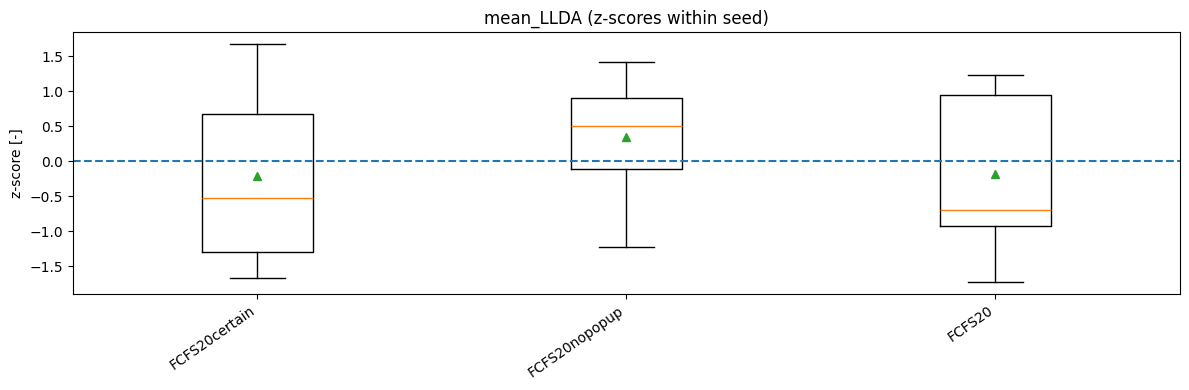

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


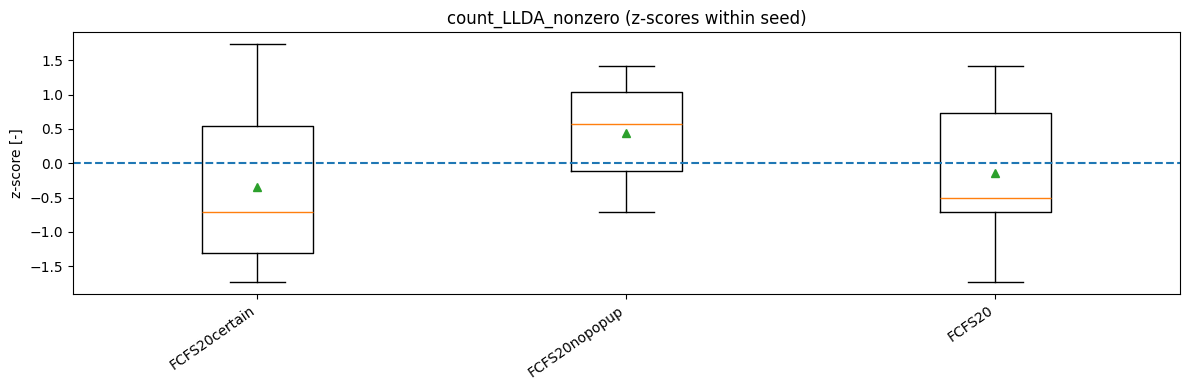

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


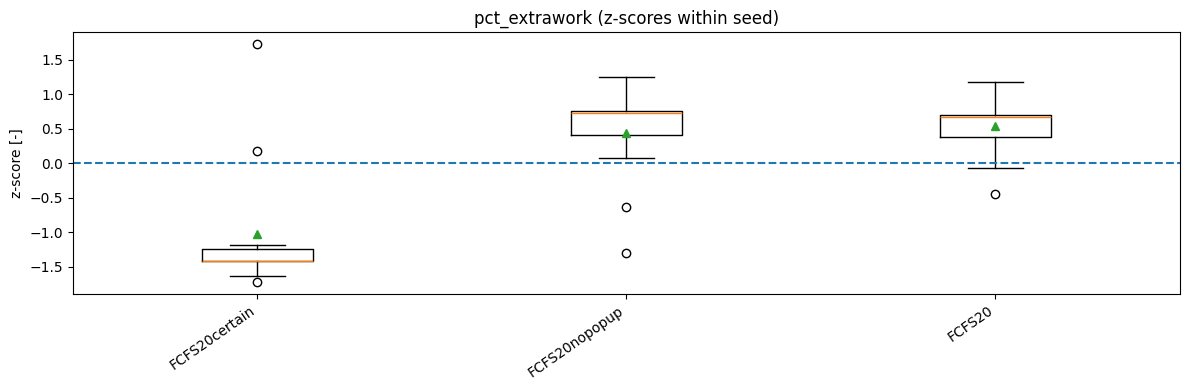

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


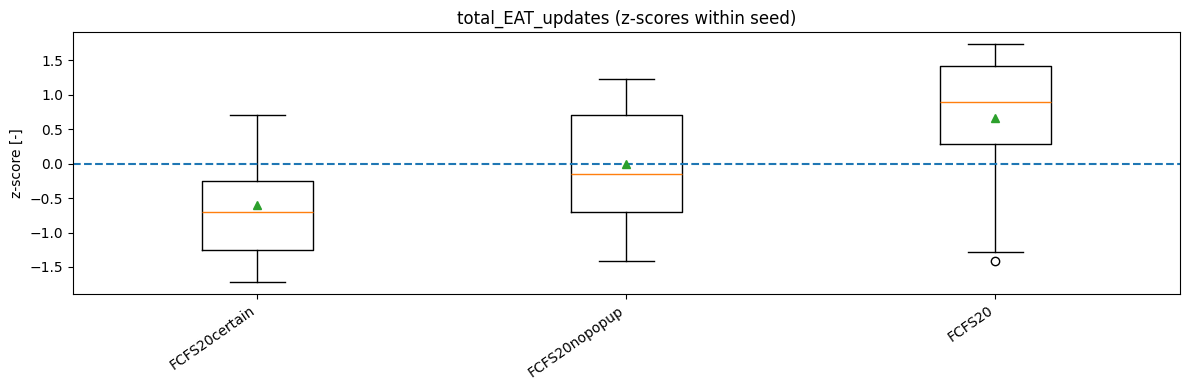

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


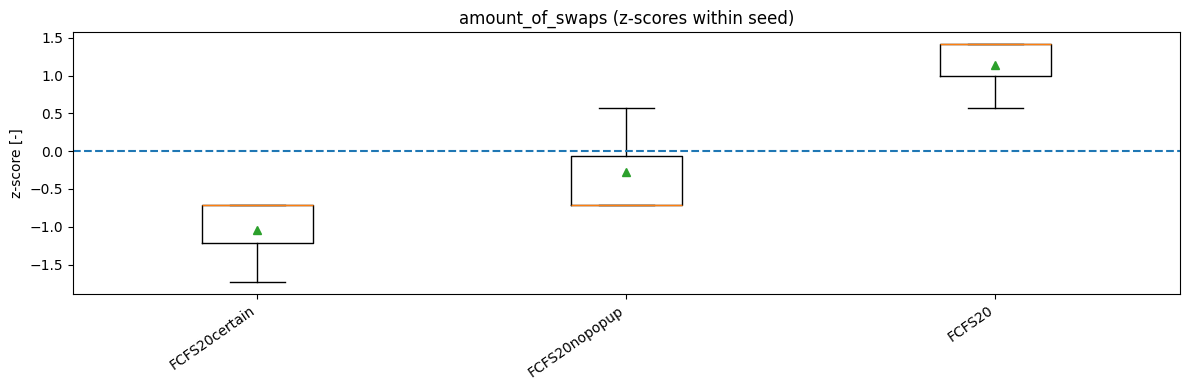

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


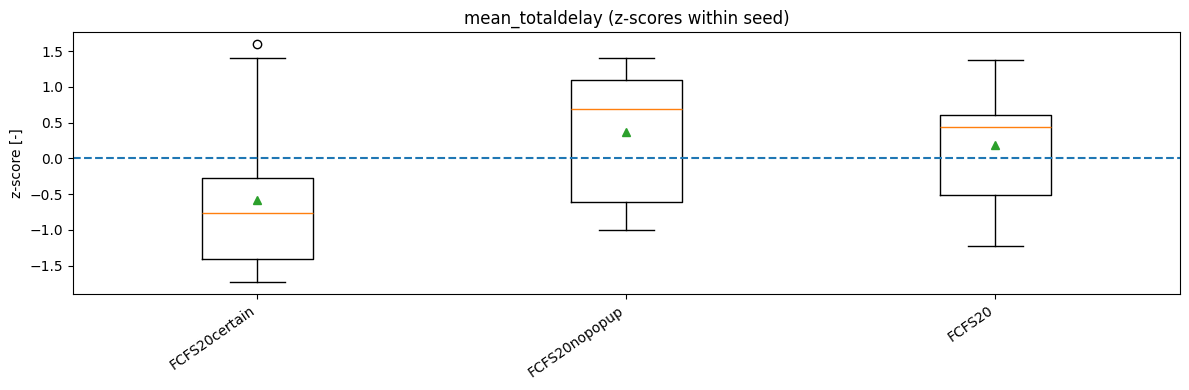

Friedman:
               measure       chi2  df         p   n  k  kendall_W  used_zscores
2       pct_extrawork  10.500000   2  0.005248  12  3   0.437500          True
3   total_EAT_updates   4.878049   2  0.087246  12  3   0.203252          True
4     amount_of_swaps   4.666667   2  0.096972   3  3   0.777778          True
5     mean_totaldelay   2.666667   2  0.263597  12  3   0.111111          True
1  count_LLDA_nonzero   2.578947   2  0.275416  11  3   0.117225          True
0           mean_LLDA   0.181818   2  0.913101  11  3   0.008264          True

Post-hoc Wilcoxon:
                measure              A              B  stat     p_raw   n  \
14     amount_of_swaps  FCFS20nopopup         FCFS20   0.0  0.179712   3   
13     amount_of_swaps  FCFS20certain         FCFS20   0.0  0.250000   3   
12     amount_of_swaps  FCFS20certain  FCFS20nopopup   0.0  0.317311   3   
5   count_LLDA_nonzero  FCFS20nopopup         FCFS20   8.0  0.161429  11   
3   count_LLDA_nonzero  FCFS20certa

/Users/jornvanbeek/Documents/Thesis/interpreter/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


In [8]:
# %% ==========================================
# EXP 1 — effect of uncertainty (compare configs)
# =============================================

# Set which column defines the compared conditions (only change if needed)
seed_col = SEED_COL
config_col = COND_COL

# Conditions to compare (edit these strings to your actual labels)
configs = [
    "FCFS20certain",          # example: zero uncertainty / deterministic
    "FCFS20nopopup",
    "FCFS20"
    # example: uncertainty on
    # add more if you want (Friedman needs >=3; Wilcoxon works pairwise anyway)
]

measures = MEASURES  # only change if there is a reason: e.g. measures = MEASURES_DELAY

# Run
d_z, wide_z = zscores_and_boxplots(df, seed_col, config_col, configs, measures, make_plots=MAKE_PLOTS)
friedman_results, _ = friedman_anova(df, seed_col, config_col, configs, measures, use_zscores=USE_ZSCORES)
posthoc = wilcoxon_posthoc(df, seed_col, config_col, configs, measures, use_zscores=USE_ZSCORES, correction=P_CORR)

print("Friedman:\n", friedman_results)
print("\nPost-hoc Wilcoxon:\n", posthoc)

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


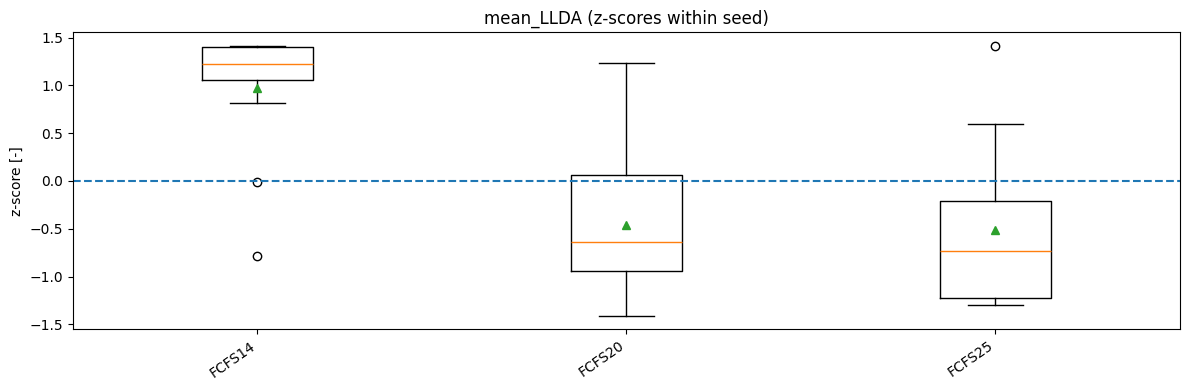

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


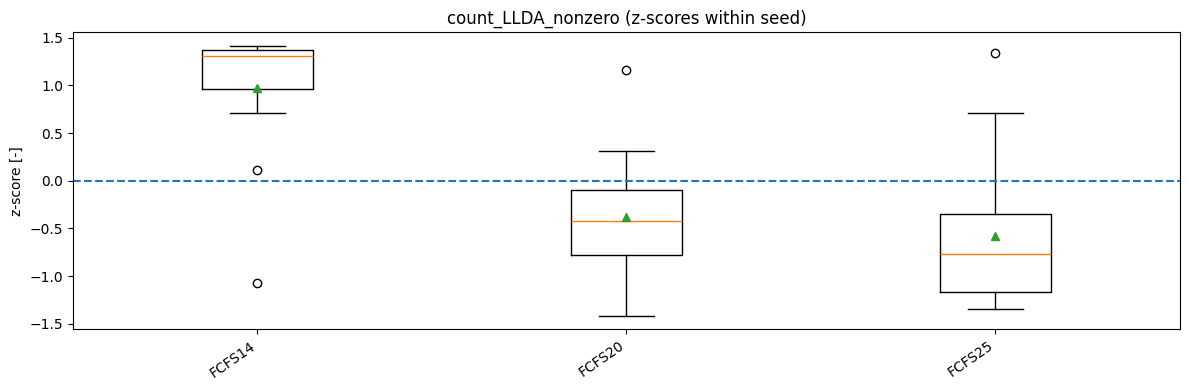

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


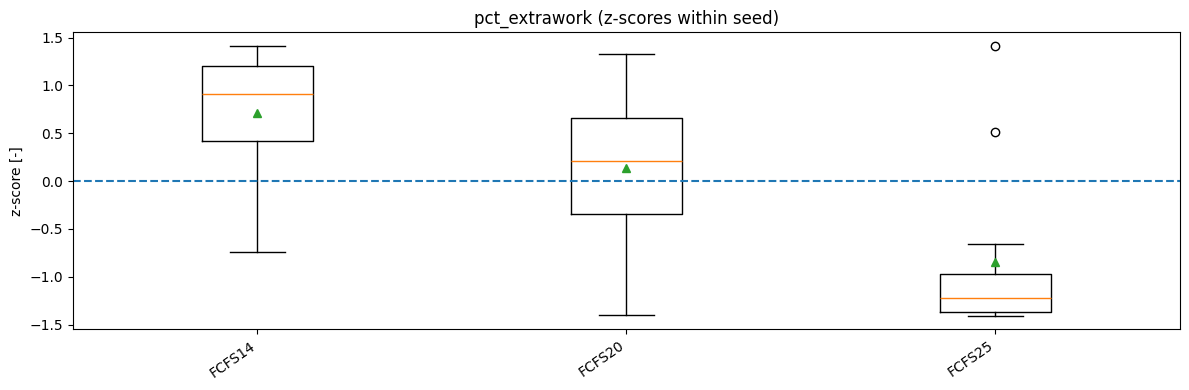

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


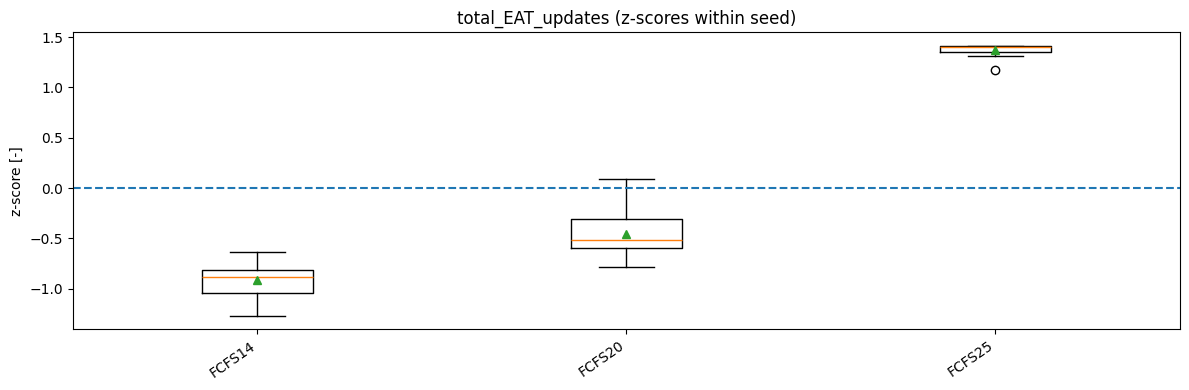

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


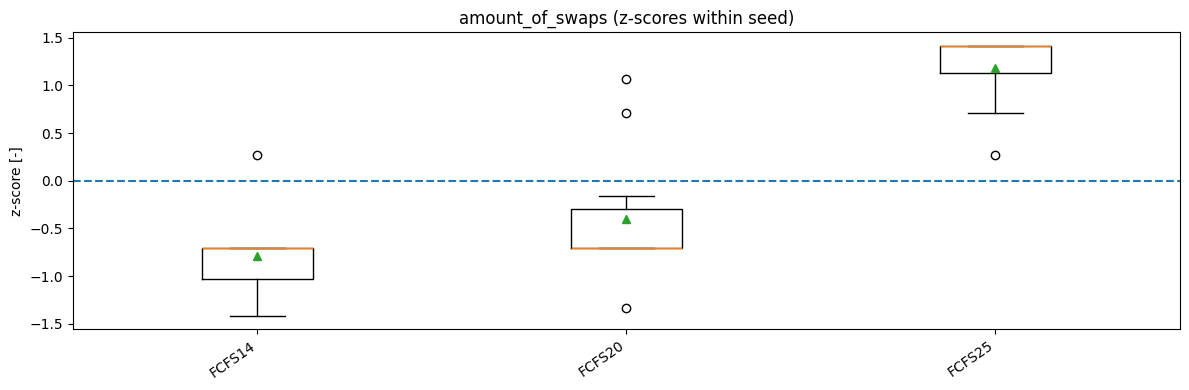

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


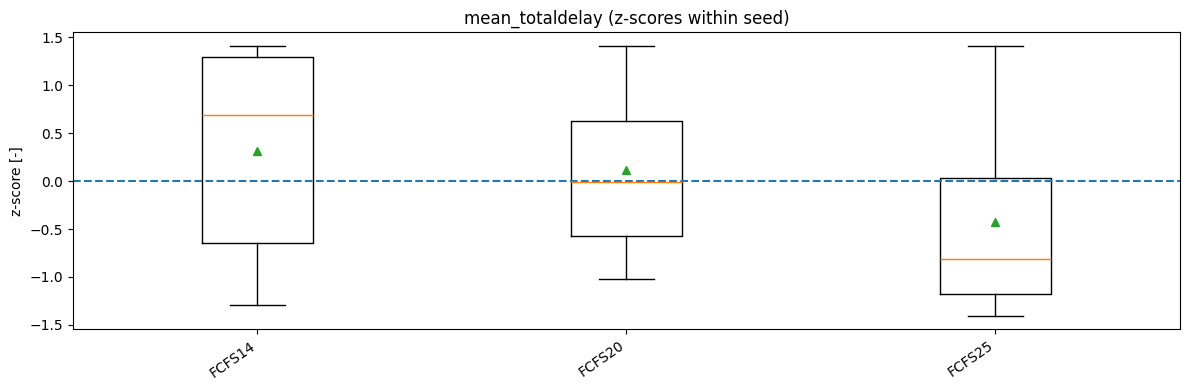

Friedman:
               measure       chi2  df         p   n  k  kendall_W  used_zscores
3   total_EAT_updates  22.166667   2  0.000015  12  3   0.923611          True
4     amount_of_swaps  13.878788   2  0.000969  10  3   0.693939          True
0           mean_LLDA  10.166667   2  0.006199  12  3   0.423611          True
1  count_LLDA_nonzero   9.911111   2  0.007044  12  3   0.412963          True
2       pct_extrawork   9.500000   2  0.008652  12  3   0.395833          True
5     mean_totaldelay   3.166667   2  0.205290  12  3   0.131944          True

Post-hoc Wilcoxon:
                measure       A       B  stat     p_raw   n  median_diff  \
13     amount_of_swaps  FCFS14  FCFS25   0.0  0.001953  10    -2.121320   
14     amount_of_swaps  FCFS20  FCFS25   1.0  0.010110  10    -2.121320   
12     amount_of_swaps  FCFS14  FCFS20   2.0  0.273322  10     0.000000   
3   count_LLDA_nonzero  FCFS14  FCFS20   5.0  0.004883  12     1.790377   
4   count_LLDA_nonzero  FCFS14  FCFS25  

In [10]:
# %% ==================================================
# EXP 2 — effect of horizon extension (compare horizons)
# =====================================================

seed_col = SEED_COL
config_col = COND_COL

configs = [
    "FCFS14",              # example: baseline horizon
    "FCFS20",              # example: extended horizon
    "FCFS25",              # example: extra extended horizon (optional)
]

measures = MEASURES  # often keep default; delay/stability measures are most relevant here

d_z, wide_z = zscores_and_boxplots(df, seed_col, config_col, configs, measures, make_plots=MAKE_PLOTS)
friedman_results, _ = friedman_anova(df, seed_col, config_col, configs, measures, use_zscores=USE_ZSCORES)
posthoc = wilcoxon_posthoc(df, seed_col, config_col, configs, measures, use_zscores=USE_ZSCORES, correction=P_CORR)

print("Friedman:\n", friedman_results)
print("\nPost-hoc Wilcoxon:\n", posthoc)

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


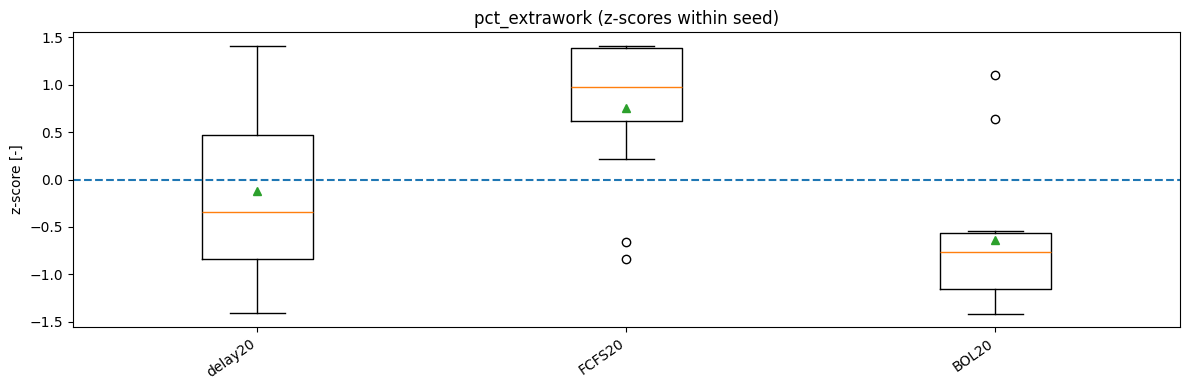

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


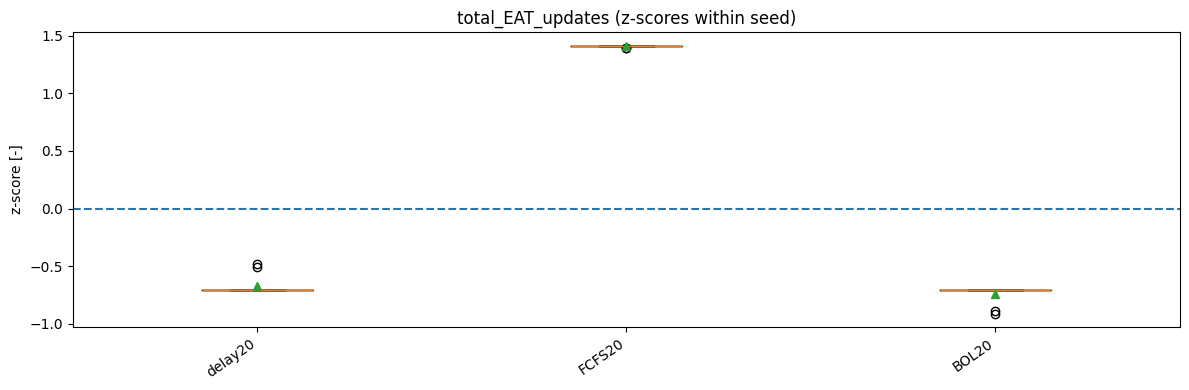

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


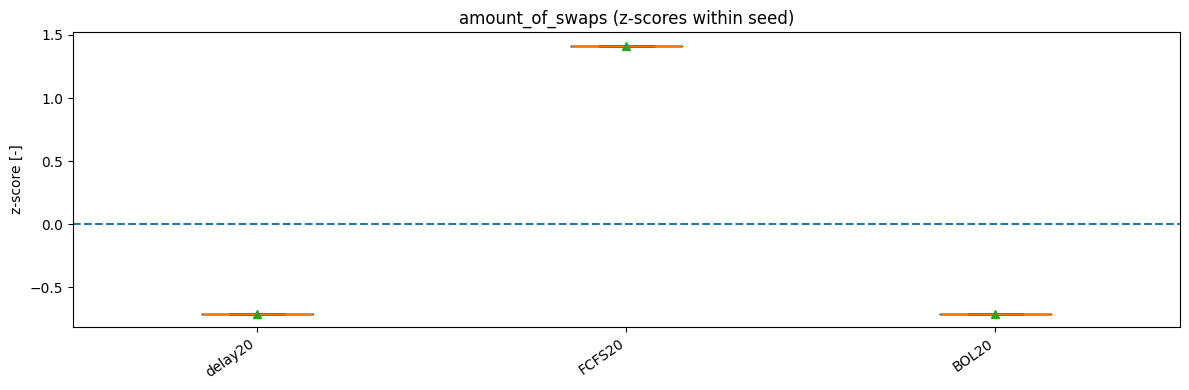

Friedman:
              measure       chi2  df         p   n  k  kendall_W  used_zscores
1  total_EAT_updates  22.947368   2  0.000010  12  3   0.956140          True
0      pct_extrawork   8.666667   2  0.013124  12  3   0.361111          True
2    amount_of_swaps   4.000000   2  0.135335   2  3   1.000000          True

Post-hoc Wilcoxon:
              measure        A       B  stat     p_raw   n  median_diff  \
6    amount_of_swaps  delay20  FCFS20   0.0  0.500000   2    -2.121320   
8    amount_of_swaps   FCFS20   BOL20   0.0  0.500000   2     2.121320   
7    amount_of_swaps  delay20   BOL20   0.0  1.000000   2     0.000000   
2      pct_extrawork   FCFS20   BOL20   7.0  0.009277  12     2.072098   
0      pct_extrawork  delay20  FCFS20  19.0  0.129395  12    -1.557356   
1      pct_extrawork  delay20   BOL20  26.0  0.339355  12     0.672592   
3  total_EAT_updates  delay20  FCFS20   0.0  0.000488  12    -2.121320   
5  total_EAT_updates   FCFS20   BOL20   0.0  0.000488  12     2.

In [11]:
# %% ===================================================
# EXP 3 — different schedulers (same horizon, compare)
# =====================================================

seed_col = SEED_COL
config_col = COND_COL

configs = [
    "delay20",             # example labels
    "FCFS20",
    "BOL20",
]

measures = MEASURES_WORKLOAD  # scheduler comparison often: workload/stability; change if you want

d_z, wide_z = zscores_and_boxplots(df, seed_col, config_col, configs, measures, make_plots=MAKE_PLOTS)
friedman_results, _ = friedman_anova(df, seed_col, config_col, configs, measures, use_zscores=USE_ZSCORES)
posthoc = wilcoxon_posthoc(df, seed_col, config_col, configs, measures, use_zscores=USE_ZSCORES, correction=P_CORR)

print("Friedman:\n", friedman_results)
print("\nPost-hoc Wilcoxon:\n", posthoc)

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


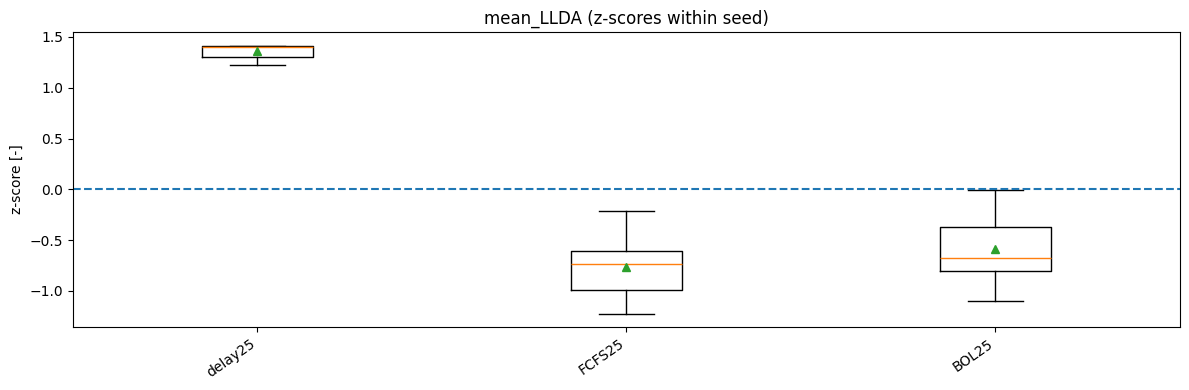

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


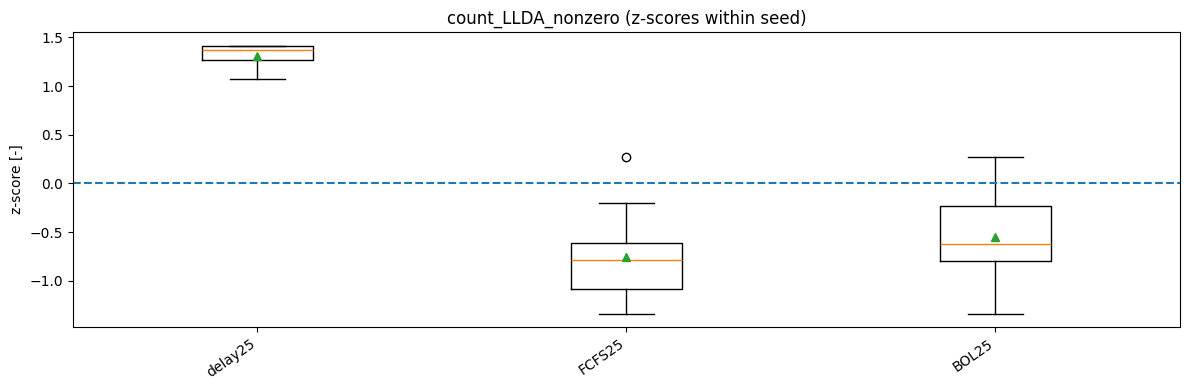

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


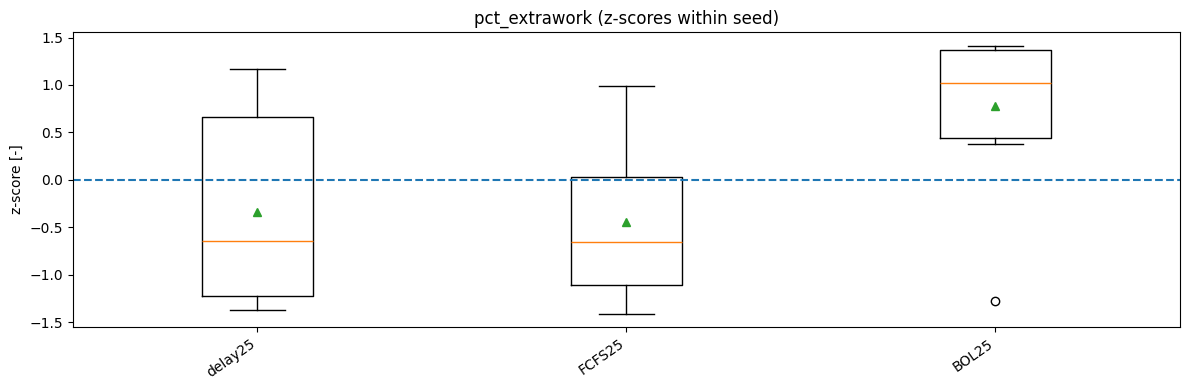

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


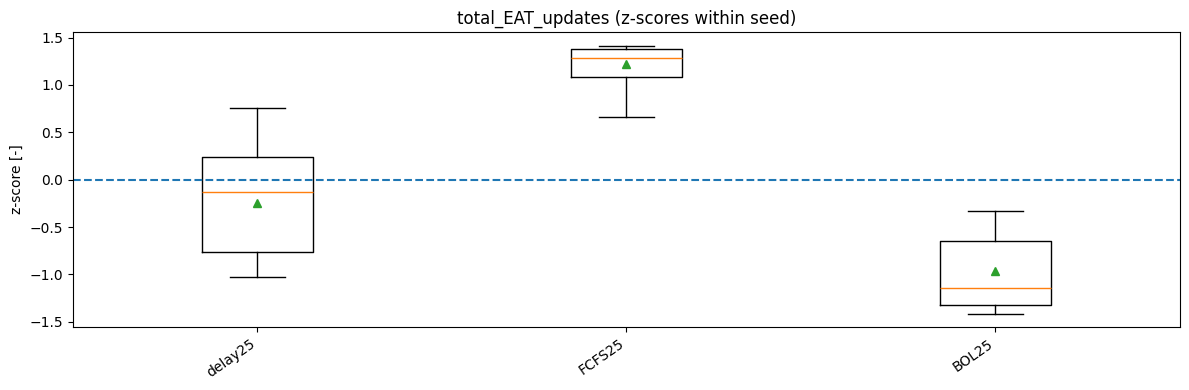

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


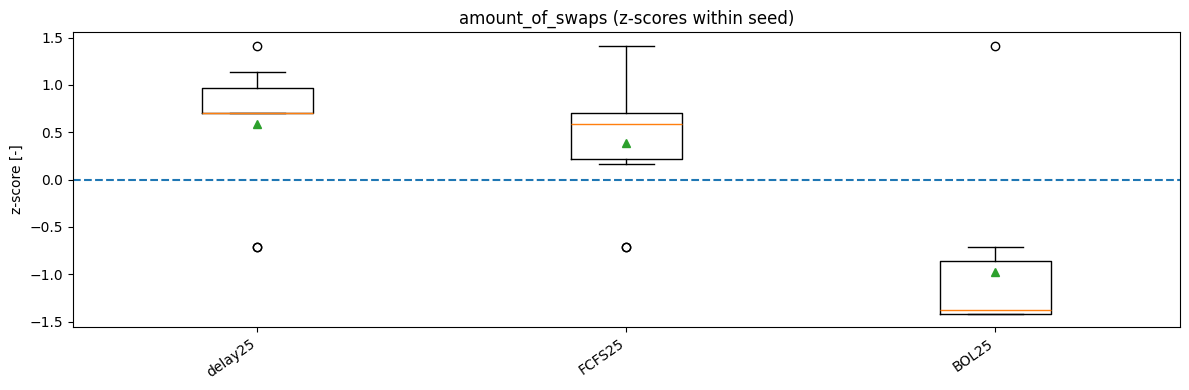

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_26336/1012142913.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


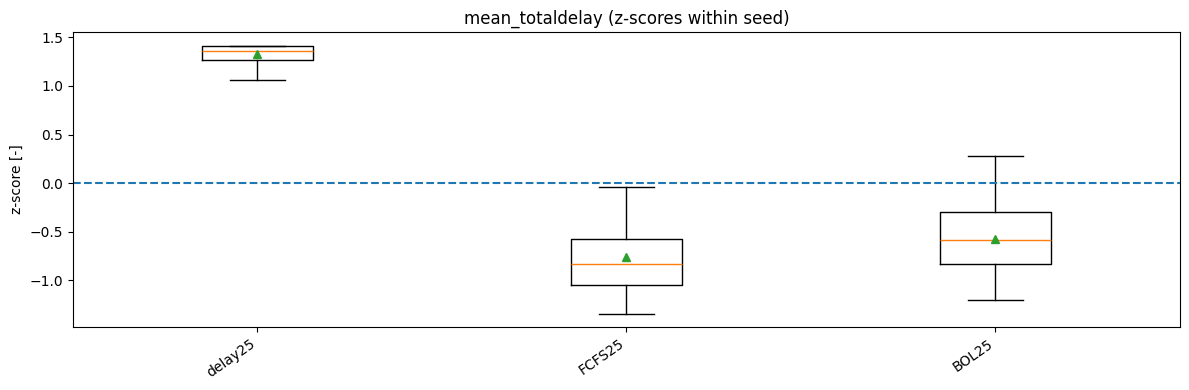

Friedman:
               measure       chi2  df         p   n  k  kendall_W  used_zscores
1  count_LLDA_nonzero  18.956522   2  0.000076  12  3   0.789855          True
5     mean_totaldelay  18.666667   2  0.000088  12  3   0.777778          True
0           mean_LLDA  18.000000   2  0.000123  12  3   0.750000          True
3   total_EAT_updates  16.166667   2  0.000309  12  3   0.673611          True
4     amount_of_swaps   9.454545   2  0.008851  10  3   0.472727          True
2       pct_extrawork   4.500000   2  0.105399  12  3   0.187500          True

Post-hoc Wilcoxon:
                measure        A       B  stat     p_raw   n  median_diff  \
13     amount_of_swaps  delay25   BOL25   3.5  0.020158  10     2.121320   
14     amount_of_swaps   FCFS25   BOL25   6.0  0.046594  10     1.986480   
12     amount_of_swaps  delay25  FCFS25   5.0  0.500184  10     0.000000   
3   count_LLDA_nonzero  delay25  FCFS25   0.0  0.000488  12     2.192904   
4   count_LLDA_nonzero  delay25   B

In [12]:
# %% ==================================================================
# EXP 4 — different schedulers with extra-extended horizon (compare)
# ====================================================================

seed_col = SEED_COL
config_col = COND_COL

configs = [
    "delay25",        # example: same schedulers but now with extra-extended FH
    "FCFS25",
    "BOL25",
]

measures = MEASURES  # here you often want both delay + workload; default set is fine

d_z, wide_z = zscores_and_boxplots(df, seed_col, config_col, configs, measures, make_plots=MAKE_PLOTS)
friedman_results, _ = friedman_anova(df, seed_col, config_col, configs, measures, use_zscores=USE_ZSCORES)
posthoc = wilcoxon_posthoc(df, seed_col, config_col, configs, measures, use_zscores=USE_ZSCORES, correction=P_CORR)

print("Friedman:\n", friedman_results)
print("\nPost-hoc Wilcoxon:\n", posthoc)